# Semantic Chunking

Every splitter in the previous lesson decides where to cut by counting — characters, tokens, or occurrences of a separator. None of them read the text. A `RecursiveCharacterTextSplitter` will happily cut between a claim and its supporting evidence because that is where character 1000 fell, and it will just as happily glue two unrelated topics together because they happened to fit.

Semantic chunking asks a different question: **where does the meaning change?** It embeds the sentences, measures how much consecutive sentences differ, and cuts where the difference spikes.

The approach was [first proposed by Greg Kamradt](https://youtu.be/8OJC21T2SL4?t=1933) and subsequently [implemented in LangChain](https://python.langchain.com/docs/how_to/semantic-chunker/) as `SemanticChunker`.

It is a genuinely better idea, and it is not free. This lesson covers how it works, builds it from scratch so the mechanism is visible, uses the library version, runs it end to end over a real 33-page PDF, and — most importantly — establishes when the extra cost is and is not worth paying.

## Learning objectives

By the end of this notebook you will be able to:

1. **Explain the algorithm**: sentence-split, embed, measure consecutive distance, threshold, group.
2. **Implement it from scratch** in about fifteen lines, so `SemanticChunker` stops being a black box.
3. **Use `SemanticChunker`** and choose between its four breakpoint threshold types.
4. **See the boundaries it finds** that a character splitter misses — on text with a deliberate topic shift.
5. **Build a complete retrieval pipeline** on a real document: PDF → semantic chunks → FAISS → retriever → inspected context.
6. **Account for its costs**: an embedding pass over every sentence at index time, unbounded chunk sizes, and sensitivity to sentence segmentation.
7. **Decide when to use it**, which is not always.

## The idea, before the code

**The problem.** Traditional text splitting breaks documents at arbitrary points — wherever the character or token budget happened to run out. That disrupts the flow of information, and it does so invisibly: nothing in the output tells you that a chunk ends mid-argument or that two subjects were fused into one vector.

**The claim.** Split at *natural* breakpoints instead, so semantic coherence is preserved inside each chunk. A chunk that is about one thing embeds cleanly near that thing. A chunk that is about two things embeds somewhere between them and is a strong match for neither.

The diagram below is the whole argument, and it is worth reading all the way down rather than just glancing at the top.

The top half contrasts the boundaries: fixed-size chunking cuts a paper into pieces that each straddle two sections ("Chunk 2: Rest of Methods, part of Results"), while semantic chunking aligns them with the sections themselves ("Chunk 2: Methods").

The bottom half is the part that matters, because it shows the *consequence*. Both are searched identically, by embedding similarity. Asked for the methods used to measure blood pressure, the fixed-size index returns fragments of two different chunks that must then be recombined, carrying irrelevant material along; the semantic index returns one coherent chunk that is the entire Methods section.

That is the claim in full: not "nicer boundaries", but fewer chunks retrieved, less irrelevant text in the prompt, and complete context. Whether it holds on *your* corpus is what Parts 4 and 6 test.

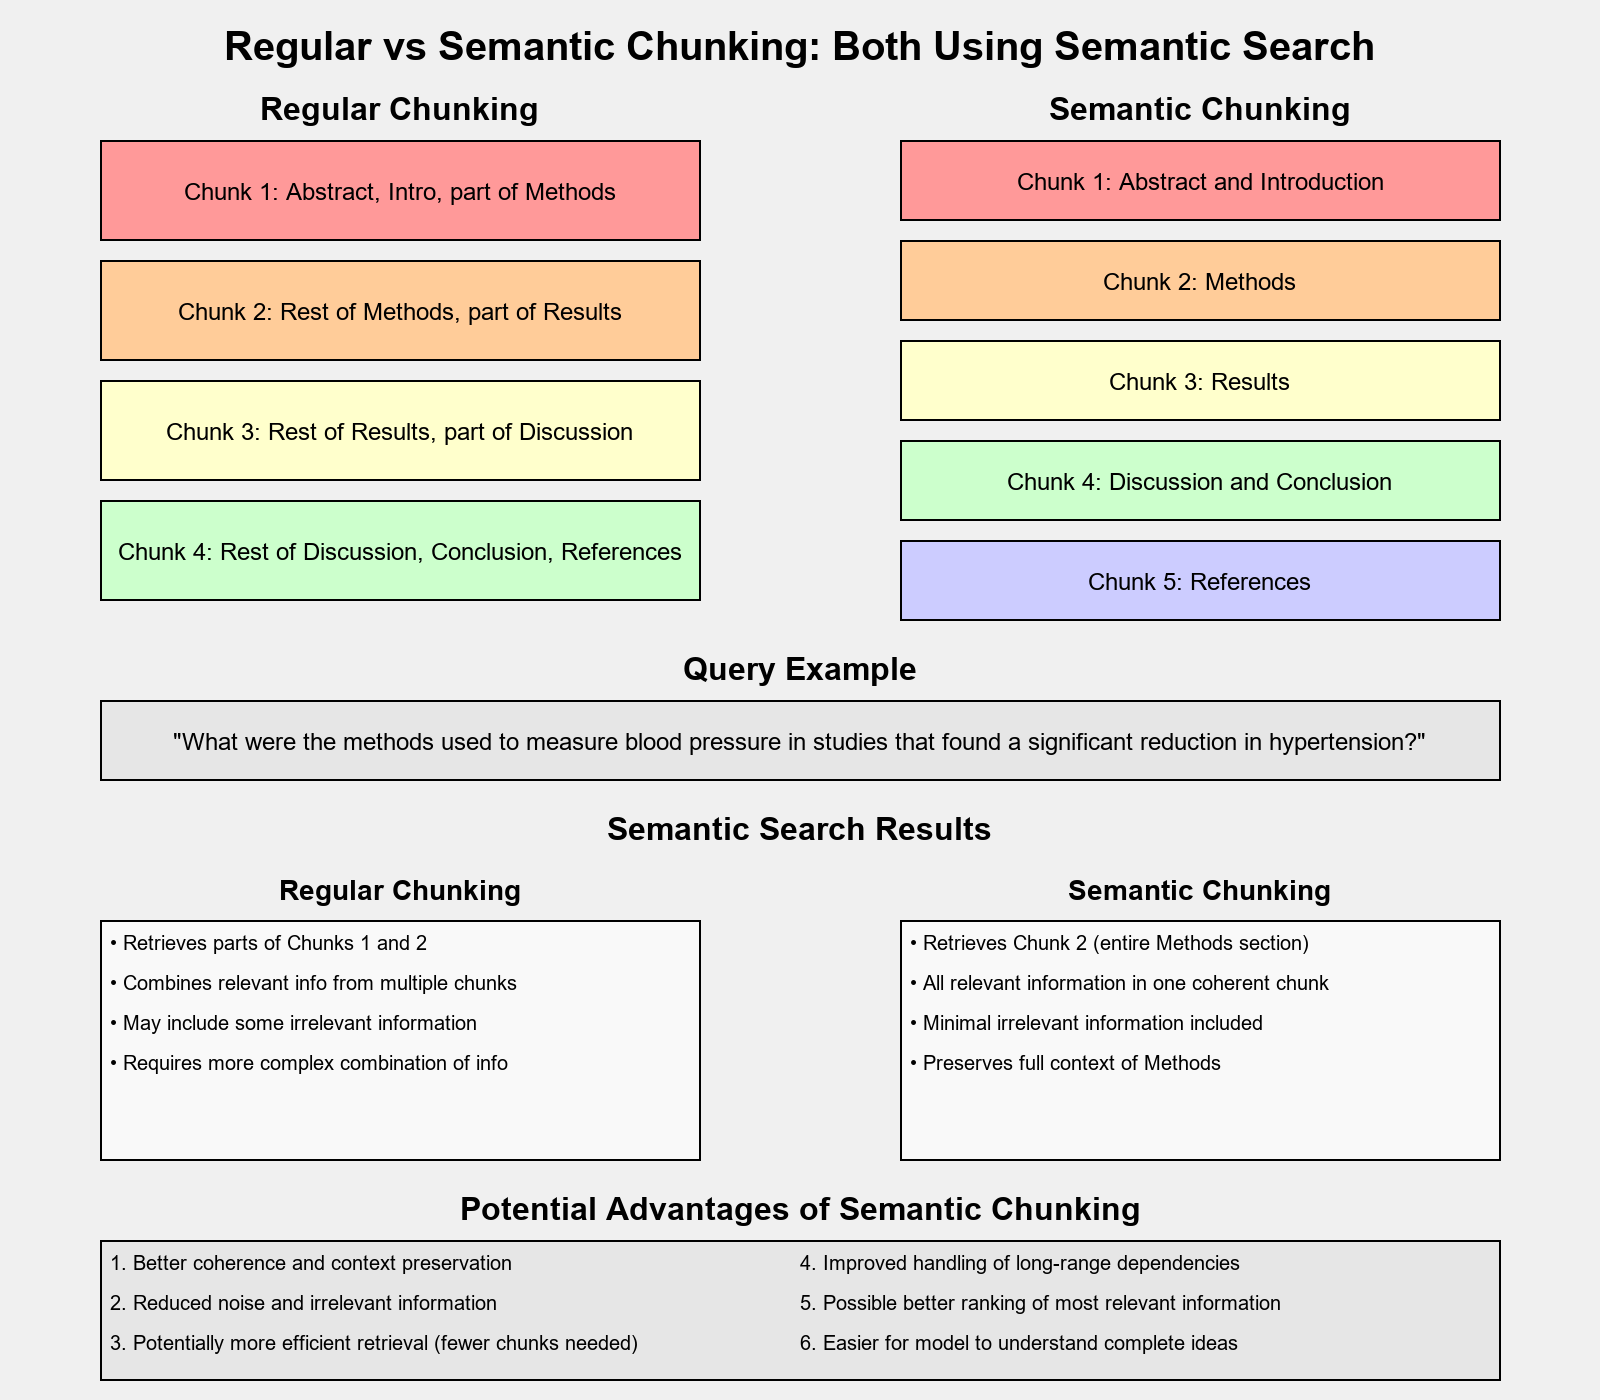

**The method, in four stages.** These map onto the parts of this notebook:

| Stage | What happens | Where |
| --- | --- | --- |
| Preprocessing | Read the document to a continuous string; page and line breaks are artifacts of the file format, not of the argument | Part 6 |
| Semantic chunking | Sentence-split, embed, measure consecutive distance, threshold, group | Parts 2–3 |
| Vector store creation | Embed the resulting chunks and index them for nearest-neighbour search | Part 6 |
| Retriever setup | Fetch the top *k* chunks for a query and inspect what came back | Part 6 |

**The benefits claimed for it**, each of which this lesson tries to check rather than assert:

- **Improved coherence** — chunks are more likely to contain a complete thought (Parts 1–3).
- **Better retrieval relevance** — preserved context should sharpen the match (Part 4 measures this).
- **Adaptability** — the breakpoint strategy and threshold are tunable per corpus (Part 3).

It is claimed to matter most for long, complex documents where context is load-bearing: scientific papers, legal documents, comprehensive reports. Part 6 runs it over one of those. Part 7 is the counter-argument.

## Prerequisites

**Lessons**

- `02_Chunking_and_Indexing/01_Document_Splitting_and_Chunking.ipynb` — the splitters this improves on, and the tension it addresses.
- `01_Foundations/03_Embeddings_and_Model_Selection.ipynb` — cosine similarity and normalization; this lesson computes distances directly.
- `01_Foundations/04_Vector_Stores_and_Index_Operations.ipynb` — the FAISS index and retriever that Part 6 builds on.

**Packages**

`langchain-experimental` (for `SemanticChunker`), `langchain-openai`, `langchain-text-splitters`, `langchain-community` (FAISS and `PyPDFLoader`), `faiss-cpu`, `pypdf`, `tiktoken`, `numpy`, `pandas`.

`SemanticChunker` lives in `langchain_experimental`, not `langchain`. The name is a real signal: the API has changed before and may change again.

**Services**

`OPENAI_API_KEY`. Unlike the previous lesson, **semantic chunking requires embeddings at chunk time** — that is the central cost, and Part 5 measures it.

**Input assets**

Both resolved via `rag_paths.asset()`:

- `langchain_intro.txt` — a short file with a deliberate topic shift, which is exactly what Parts 1–5 need to demonstrate the mechanism at a size where every chunk can be printed and read.
- `Understanding_Climate_Change.pdf` — a 33-page report, ~13k tokens. Part 6 uses it because a method that only works on five hand-picked sentences has not been shown to work.

## Provenance and runtime status

Consolidated from:

| Source | Contribution |
| --- | --- |
| `08_Advanced_RAG/Comprehensive_RAG_Techniques/all_rag_techniques/semantic_chunking.ipynb` | **Canonical explanation.** The conceptual framing above (problem, claim, method stages, claimed benefits), the Kamradt/LangChain attribution, the `semantic_chunking_comparison.svg` diagram, the breakpoint-threshold types, and the end-to-end PDF → `SemanticChunker` → FAISS → retriever pipeline with the climate-change query in Part 6. |
| `04_Retrieval_and_RAG/06_RAG_Naive_to_Production/02_Splitting_and_Chunking/2. Semantichunking.ipynb` | The from-scratch implementation, and `langchain_intro.txt` — a corpus built specifically to have a topic shift. |

**Adapted, not copied, from the canonical source:** it calls `read_pdf_to_string` and `retrieve_context_per_question`/`show_context` from an anthology-local `helper_functions` module via `from helper_functions import *`. Part 6 uses `PyPDFLoader` and an explicit `show_context` instead, so the lesson has no dependency on the anthology folder's layout. Its three breakpoint types are also extended to four — `gradient` was added to `SemanticChunker` after the source was written.

**A defect in the second source:** it is written entirely against LangChain 0.x — `langchain.chat_models`, `langchain.document_loaders`, `langchain.vectorstores`, `langchain.schema`, `langchain.prompts`. All of those raise `ModuleNotFoundError` on this repository's LangChain 1.4. It also depends on `sentence_transformers`, which is not installed here (the `hf` extra). It cannot run as written.

**Added here, present in neither source:** the cost measurement in Part 5, the separation test in Part 4, the comparison against a character splitter on the same text, and the guidance on when *not* to use semantic chunking. Both sources demonstrate the technique working and stop there.

**Runtime status:** see `RAG_MIGRATION_MANIFEST.md`.

---

## Part 0 — Setup

In [ ]:
# ============ BOOTSTRAP: DEPTH-INDEPENDENT PATHS ============
import pathlib
import sys

_p = pathlib.Path.cwd()
while not (_p / "RAG_Curriculum").is_dir() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p / "RAG_Curriculum" / "_support" / "helpers"))

from rag_paths import asset, repo_root

In [ ]:
# ============ IMPORTS AND ENVIRONMENT ============
import re
import time

import numpy as np
import pandas as pd
import tiktoken
from dotenv import load_dotenv

# FAISS and PyPDFLoader still live in langchain_community on LangChain 1.4;
# no standalone package exists for either yet.
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv(repo_root() / ".env")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
enc = tiktoken.get_encoding("cl100k_base")

print("Ready:", embeddings.model)

In [ ]:
# ============ THE CORPUS ============
# Deliberately constructed: it talks about LangChain, then abruptly switches
# to Paris and France. A character splitter has no way to notice that.
text = asset("langchain_intro.txt").read_text(encoding="utf-8").strip()

print(f"{len(text)} characters\n")
for i, line in enumerate(text.splitlines()):
    print(f"  {i}: {line}")

---

## Part 1 — What a character splitter does with this

Before introducing the new technique, establish the baseline honestly: what does the previous lesson's default do here, and is it actually wrong?

In [ ]:
# ============ BASELINE: RECURSIVE CHARACTER SPLITTING ============
baseline = RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=0).split_text(text)

print(f"RecursiveCharacterTextSplitter(150) -> {len(baseline)} chunks\n")
for i, c in enumerate(baseline):
    print(f"--- chunk {i} ({len(c)} chars) ---")
    print(c)
    print()

Look at whether any chunk mixes the LangChain material with the Paris material. At this size the split may land near the topic boundary by luck — the paragraph break is there, and `RecursiveCharacterTextSplitter` splits on `\n` before falling back to words.

**That is worth stating plainly: on well-structured text, character splitting often gets the boundary right for free**, because authors already mark topic changes with paragraph breaks. Semantic chunking earns its cost on text where that structure is *absent or misleading* — transcripts, OCR output, scraped pages, or long unbroken prose.

Watch what happens when the structural cue is removed.

In [ ]:
# ============ THE HARD CASE: STRUCTURE REMOVED ============
# Collapse the newlines. Now there is no paragraph break to split on - the
# text is one continuous run, and the topic shift is invisible to any
# character-counting splitter.
flat = " ".join(line.strip() for line in text.splitlines() if line.strip())
print(f"{len(flat)} characters, no line breaks:\n")
print(flat)

flat_chunks = RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=0).split_text(flat)
print(f"\n-> {len(flat_chunks)} chunks\n")
for i, c in enumerate(flat_chunks):
    print(f"--- chunk {i} ---")
    print(c)
    print()

Now inspect the chunks: one of them contains the tail of the LangChain material *and* both France sentences. The cut landed where the character count expired, which is mid-topic.

That chunk's embedding is a blend of two unrelated subjects, so it sits between them rather than squarely on either. Part 4 measures exactly how much that costs — it is a smaller effect than you might expect on a five-sentence corpus, and a decisive one at scale.

This is the failure semantic chunking exists to fix.

---

## Part 2 — The algorithm, from scratch

Five steps. Implementing it takes about fifteen lines, and doing so makes every parameter of the library version obvious.

1. **Split into sentences** — the atomic units that will be grouped.
2. **Embed each sentence.**
3. **Measure the distance between consecutive sentences** — `1 - cosine similarity`.
4. **Pick a threshold.** Distances above it are topic boundaries.
5. **Group** the sentences between boundaries into chunks.

In [ ]:
# ============ STEP 1: SENTENCES ============
# A regex is crude - it mishandles "Dr.", "e.g.", decimals - but it makes the
# dependency visible. Everything downstream inherits these boundaries.
sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", flat) if s.strip()]

print(f"{len(sentences)} sentences:")
for i, s in enumerate(sentences):
    print(f"  {i}: {s}")

In [ ]:
# ============ STEPS 2-3: EMBED, THEN MEASURE CONSECUTIVE DISTANCE ============
vecs = np.array(embeddings.embed_documents(sentences))   # one batched call

# Unit vectors (lesson 03), so dot product is cosine similarity.
distances = [1.0 - float(vecs[i] @ vecs[i + 1]) for i in range(len(vecs) - 1)]

print(f"{'gap':>5}  {'distance':>9}   between")
for i, d in enumerate(distances):
    print(f"{i:>2}-{i+1:<2} {d:>9.4f}   {sentences[i][:34]!r} | {sentences[i+1][:34]!r}")

print(f"\nmean {np.mean(distances):.4f}   max {np.max(distances):.4f} "
      f"at gap {int(np.argmax(distances))}-{int(np.argmax(distances)) + 1}")

The distance series is the whole signal. Consecutive sentences on the same topic sit close together; the sentence that changes subject shows a spike.

Note that this measures **local** change only — sentence *i* against sentence *i+1*. It has no notion of a chunk drifting gradually off-topic over five sentences, none of which differs much from its neighbour. Gradual drift is invisible to this method.

In [ ]:
# ============ STEPS 4-5: THRESHOLD AND GROUP ============
# Percentile thresholding: treat the top X% of distances as boundaries.
# Absolute thresholds do not transfer between texts or embedding models;
# a percentile adapts to the distribution at hand.
def semantic_chunks(sentences, distances, percentile=90):
    if not distances:
        return sentences
    cutoff = np.percentile(distances, percentile)
    breaks = [i for i, d in enumerate(distances) if d > cutoff]

    chunks, start = [], 0
    for b in breaks:
        chunks.append(" ".join(sentences[start:b + 1]))
        start = b + 1
    chunks.append(" ".join(sentences[start:]))
    return [c for c in chunks if c.strip()], cutoff, breaks


chunks, cutoff, breaks = semantic_chunks(sentences, distances, percentile=90)

print(f"cutoff (90th percentile) = {cutoff:.4f}")
print(f"boundaries after sentences: {breaks}\n")
for i, c in enumerate(chunks):
    print(f"--- chunk {i} ({len(c)} chars) ---")
    print(c)
    print()

Compare that against the flat-text character chunks from Part 1. The boundary should now fall exactly where the subject changes — because that is what was measured, rather than where a character count expired.

---

## Part 3 — `SemanticChunker`

The library version does the same five steps with more care: a better sentence splitter, a configurable buffer that compares small *groups* of sentences rather than single ones, and four threshold strategies.

In [ ]:
# ============ SemanticChunker: THE LIBRARY IMPLEMENTATION ============
chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=90,
)

t0 = time.perf_counter()
lib_chunks = chunker.split_text(flat)
elapsed = time.perf_counter() - t0

print(f"SemanticChunker -> {len(lib_chunks)} chunks in {elapsed:.2f}s\n")
for i, c in enumerate(lib_chunks):
    print(f"--- chunk {i} ({len(c)} chars) ---")
    print(c)
    print()

### The four threshold types

| `breakpoint_threshold_type` | Splits when a distance is… | `breakpoint_threshold_amount` | Behaviour |
| --- | --- | --- | --- |
| `"percentile"` (default) | above the Nth percentile | 95 | Predictable chunk *count*; always finds boundaries even in uniform text |
| `"standard_deviation"` | more than N σ above the mean | 3 | Finds genuine outliers; may find none at all |
| `"interquartile"` | beyond N × IQR | 1.5 | Robust to a few extreme values |
| `"gradient"` | at a peak in the *rate of change* | 95 | For text where topics shift gradually rather than abruptly |

The first three are the ones described in the original technique; `gradient` was added later.

The distinction that matters: **`percentile` always splits** — the 95th percentile of any distribution exists, even if the text never changes topic. `standard_deviation` and `interquartile` can legitimately return one chunk for a document that is genuinely about one thing.

In [ ]:
# ============ COMPARING THRESHOLD TYPES ============
rows = []
for ttype, amount in [
    ("percentile", 90),
    ("percentile", 95),
    ("standard_deviation", 1.0),
    ("standard_deviation", 3.0),
    ("interquartile", 1.5),
]:
    out = SemanticChunker(
        embeddings,
        breakpoint_threshold_type=ttype,
        breakpoint_threshold_amount=amount,
    ).split_text(flat)
    sizes = [len(c) for c in out]
    rows.append({"type": ttype, "amount": amount, "chunks": len(out),
                 "min_chars": min(sizes), "max_chars": max(sizes)})

print(pd.DataFrame(rows).to_string(index=False))
print("\nNote `standard_deviation` at 3.0: on a short text with few sentences,")
print("no distance is 3 sigma above the mean, so it returns ONE chunk.")
print("That is correct behaviour, not a failure - but it means chunk sizes")
print("are unbounded, which Part 5 returns to.")

---

## Part 4 — Verifying the boundary is real

A chunking method that produces boundaries is easy. Producing boundaries that *help retrieval* is the claim, and it is checkable: chunks about one topic should be close to that topic's query and far from the other's.

In [ ]:
# ============ DO THE CHUNKS SEPARATE CLEANLY? ============
queries = {
    "framework query": "What is LangChain used for?",
    "geography query": "Where is the Eiffel Tower?",
}
q_vecs = {k: np.array(embeddings.embed_query(v)) for k, v in queries.items()}


def separation(chunk_list, label):
    """Similarity of each chunk to each query, and the MARGIN between them.

    Margin is the signal: a topically clean chunk is much closer to one query
    than the other. A mixed chunk sits between them and serves neither well.
    """
    c_vecs = np.array(embeddings.embed_documents(chunk_list))
    print(f"{label}")
    print(f"  {'chunk':>5} {'framework':>10} {'geography':>10} {'margin':>8}")
    margins = []
    for i, cv in enumerate(c_vecs):
        a = float(cv @ q_vecs["framework query"])
        b = float(cv @ q_vecs["geography query"])
        margins.append(abs(a - b))
        print(f"  {i:>5} {a:>10.4f} {b:>10.4f} {abs(a - b):>8.4f}")
    print(f"  mean margin: {np.mean(margins):.4f}")
    print()
    return float(np.mean(margins))


m_char = separation(flat_chunks, "Character splitter on flat text:")
m_sem = separation(lib_chunks, "SemanticChunker on the same text:")
print(f"Semantic chunking sharpened the mean margin "
      f"{m_char:.4f} -> {m_sem:.4f} ({m_sem / m_char:.2f}x)")

**Read the `margin` column, not the verdicts.** Both methods put each chunk nearer one query than the other — the character splitter is not catastrophically wrong here. The difference is *how decisively*.

The character splitter's second chunk contains the tail of the LangChain material *and* both France sentences. Its vector is a blend, so it lands between the two queries: still closer to geography, but with a smaller margin. Semantic chunking cuts exactly at the topic change, so each chunk is about one thing and the margin roughly doubles.

That margin is what determines whether the right chunk beats a competitor in a large index. On a five-sentence corpus a blended chunk still wins its query; among a hundred thousand chunks it does not. This is the same reasoning as the `margin` metric in `01_Foundations/03` — a binary hit/miss verdict saturates and stops discriminating, while the margin keeps telling you something.

Measure this on your own corpus before adopting the technique, rather than taking it on faith.

---

## Part 5 — The cost

Semantic chunking embeds every sentence in your corpus **before** you embed the chunks. That is an extra full pass over all your text at index time.

In [ ]:
# ============ MEASURING THE OVERHEAD ============
corpus_tokens = len(enc.encode(flat))

t0 = time.perf_counter()
RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=0).split_text(flat)
t_char = time.perf_counter() - t0

t0 = time.perf_counter()
SemanticChunker(embeddings, breakpoint_threshold_type="percentile",
                breakpoint_threshold_amount=90).split_text(flat)
t_sem = time.perf_counter() - t0

print(f"{'method':<26} {'seconds':>9}  {'embeds text?':>13}")
print(f"{'RecursiveCharacter':<26} {t_char:>9.4f}  {'no':>13}")
print(f"{'SemanticChunker':<26} {t_sem:>9.4f}  {'yes':>13}")
print(f"\nratio: {t_sem / max(t_char, 1e-9):,.0f}x slower on {corpus_tokens} tokens")
print()
print("Character splitting is pure string manipulation - microseconds, free.")
print("Semantic chunking is network-bound: one embedding pass over every")
print("sentence, then the usual pass over the resulting chunks.")

Extrapolate honestly. On a 10-million-token corpus semantic chunking means embedding roughly 10 million tokens *twice* — once by sentence to find boundaries, once by chunk to index. It roughly doubles index-time embedding cost and adds substantial wall time.

Two further costs that are easy to miss:

**Chunk sizes are unbounded.** Nothing in the algorithm caps a chunk. A long stretch on one topic becomes one enormous chunk, which may exceed your embedding model's input limit (silently truncated by some providers) or blow your prompt budget at retrieval time. The mitigation is a second size-bounded split afterwards — the two-stage pattern from the previous lesson.

**It inherits its sentence splitter's mistakes.** Bad sentence segmentation means bad candidate boundaries, and no threshold tuning recovers from that. Abbreviations, decimals, bullet lists and transcripts without punctuation all degrade it.

In [ ]:
# ============ BOUNDING THE OUTPUT ============
# The safe pattern: semantic boundaries first, then a size ceiling.
semantic = SemanticChunker(embeddings, breakpoint_threshold_type="percentile",
                           breakpoint_threshold_amount=90).split_text(flat)
bounded = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", chunk_size=60, chunk_overlap=0
).split_text("\n\n".join(semantic))

print(f"semantic only     : {len(semantic)} chunks, "
      f"max {max(len(c) for c in semantic)} chars")
print(f"semantic + bounded: {len(bounded)} chunks, "
      f"max {max(len(c) for c in bounded)} chars")
print("\nTopic boundaries are respected first; the size split only intervenes")
print("where a topic ran longer than the ceiling.")

---

## Part 6 — End to end on a real document

Everything so far ran on five sentences, which is the right size for *seeing* the mechanism and the wrong size for trusting it. This part runs the full pipeline the technique was proposed for: a 33-page PDF report, chunked semantically, indexed in FAISS, queried through a retriever.

### Stage 1 — Preprocessing

In [ ]:
# ============ LOAD THE PDF ============
pdf_path = str(asset("Understanding_Climate_Change.pdf"))
pages = PyPDFLoader(pdf_path).load()

# SemanticChunker needs continuous text. Page breaks are an artifact of the
# file format, not of the argument, so join the pages back up before chunking -
# otherwise every page boundary becomes a forced chunk boundary for free, and
# the method never gets to decide anything about them.
document_text = "\n".join(p.page_content for p in pages)
doc_tokens = len(enc.encode(document_text))

print(f"{len(pages)} pages -> {len(document_text):,} characters, {doc_tokens:,} tokens")
print(f"boundary detection will embed all {doc_tokens:,} of those tokens,")
print(f"then indexing will embed them again: ~{2 * doc_tokens:,} tokens total")

### Stage 2 — Semantic chunking

In [ ]:
# ============ CHUNK THE DOCUMENT ============
# create_documents() returns Document objects rather than raw strings, which is
# what the vector store wants next.
t0 = time.perf_counter()
doc_chunks = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=90,
).create_documents([document_text])
t_doc_chunk = time.perf_counter() - t0

sizes = [len(d.page_content) for d in doc_chunks]
print(f"{len(doc_chunks)} chunks in {t_doc_chunk:.1f}s\n")
print(f"chars  min {min(sizes):>6}   median {int(np.median(sizes)):>6}   max {max(sizes):>6}")
print(f"tokens {'':>6}   {'':>6}          max {max(len(enc.encode(d.page_content)) for d in doc_chunks):>6}")
print("\nCheck that max: nothing in the algorithm bounds it. If it approaches")
print("your embedding model's input limit, apply the Part 5 bounding pattern.")

### Stage 3 — Vector store creation

In [ ]:
# ============ INDEX THE CHUNKS IN FAISS ============
t0 = time.perf_counter()
vectorstore = FAISS.from_documents(doc_chunks, embeddings)
t_index = time.perf_counter() - t0

print(f"indexed {len(doc_chunks)} chunks in {t_index:.1f}s")
print(f"index size: {vectorstore.index.ntotal} vectors x {vectorstore.index.d} dims")

### Stage 4 — Retriever setup and inspection

In [ ]:
# ============ RETRIEVE AND SHOW THE CONTEXT ============
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})


def show_context(docs, label=""):
    """Print retrieved chunks in full. Reading the context is the only way to
    tell a good retrieval from a lucky one."""
    if label:
        print(label)
    for i, d in enumerate(docs):
        print(f"--- context {i + 1} ({len(d.page_content)} chars) ---")
        print(d.page_content.strip())
        print()


test_query = "What is the main cause of climate change?"
show_context(retriever.invoke(test_query), f"Query: {test_query!r}\n")

Read those chunks rather than counting them. Two things to check:

1. **Does each chunk stand on its own?** A semantically chunked passage should read as a complete thought — not start mid-sentence, not trail off into an unrelated subject. That is the coherence claim, and this is where you can see whether it held on real prose rather than on a constructed example.
2. **Is the answer actually in there?** Coherent chunks that do not contain the answer are still a retrieval failure. Chunk quality and retrieval quality are different things.

The same query against character-split chunks makes the comparison concrete.

In [ ]:
# ============ THE SAME QUERY, CHARACTER-SPLIT ============
# Same document, same embeddings, same k. Only the boundaries differ.
char_docs = RecursiveCharacterTextSplitter(
    chunk_size=int(np.median(sizes)), chunk_overlap=0
).create_documents([document_text])

char_store = FAISS.from_documents(char_docs, embeddings)
show_context(
    char_store.as_retriever(search_kwargs={"k": 2}).invoke(test_query),
    f"Character splitter ({len(char_docs)} chunks at ~{int(np.median(sizes))} chars):\n",
)

print("Both retrieve something relevant - the useful question is whether the")
print("character-split passages start or end mid-idea, and whether that would")
print("cost you at generation time. Judge it on this document, not in general.")

---

## Part 7 — When to use it

**Use semantic chunking when:**

- The text lacks reliable structure — transcripts, OCR, scraped pages, unbroken prose.
- Topics shift *within* documents in ways paragraph breaks do not mark.
- Retrieval quality matters more than index cost, and the corpus is small enough that a doubled embedding pass is affordable.
- You have measured it, on your corpus, and it helps.

**Do not use it when:**

- The document already has structure. Markdown headings, code syntax and HTML sections are *author-supplied* boundaries — better signal than inferred ones, and free. Reach for the previous lesson's structure-aware splitters first.
- The corpus is very large. Doubling index-time embedding cost is a real budget line.
- Content is uniform — API reference pages, product records, log entries. If every entry is about one thing, there is no topic shift to find.
- You have not measured it. It is intuitively appealing, which makes it easy to adopt on faith. Parts 4 and 6 show how to check.

**The honest summary:** semantic chunking is the right tool for a specific problem — unstructured text with internal topic shifts — and is often outperformed on structured documents by a `MarkdownHeaderTextSplitter` that costs nothing. Try structure first.

---

## Limitations and tradeoffs

**Two documents.** Parts 1–5 run on a 292-character constructed file; Part 6 runs on one 33-page report. Both are demonstrations of method, not results. The separation numbers in Part 4 come from a corpus built to have exactly one obvious topic shift, and Part 6's retrieval is a single query with no ground truth attached.

**Only local change is detected.** Sentence *i* against *i+1*. A chunk that drifts gradually across five sentences never triggers a boundary. `gradient` thresholding helps somewhat; nothing solves it fully.

**`langchain_experimental` is experimental.** The package name is the warning. Pin the version if you depend on this in production.

**Threshold values do not transfer.** A percentile tuned on legal contracts will misbehave on chat transcripts. It is a per-corpus parameter, and the percentile types will always find *something* to split on.

**It is orthogonal to the completeness problem.** Semantic chunking places boundaries better; it does not solve "the chunk is too small to contain the whole answer". That is still parent-document retrieval (`06`) or context windows.

---

## Exercise

Build a `SemanticChunkingReport` that decides whether semantic chunking is worth it for a given text, rather than assuming.

In [ ]:
# ============ EXERCISE: IS IT WORTH IT HERE? ============
class SemanticChunkingReport:
    """Compare semantic against character chunking on one text, with evidence."""

    def __init__(self, embeddings, target_chars=150):
        self.embeddings = embeddings
        self.target_chars = target_chars

    def analyse(self, text: str, percentile: int = 90) -> dict:
        char_chunks = RecursiveCharacterTextSplitter(
            chunk_size=self.target_chars, chunk_overlap=0
        ).split_text(text)
        sem_chunks = SemanticChunker(
            self.embeddings,
            breakpoint_threshold_type="percentile",
            breakpoint_threshold_amount=percentile,
        ).split_text(text)

        # How separable are the distances? A text with a real topic shift has
        # a high max-to-median ratio; uniform text does not.
        sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
        v = np.array(self.embeddings.embed_documents(sents))
        d = [1.0 - float(v[i] @ v[i + 1]) for i in range(len(v) - 1)] or [0.0]

        return {
            "sentences": len(sents),
            "char_chunks": len(char_chunks),
            "semantic_chunks": len(sem_chunks),
            "semantic_max_chars": max(len(c) for c in sem_chunks),
            "distance_median": round(float(np.median(d)), 4),
            "distance_max": round(float(np.max(d)), 4),
            "peak_ratio": round(float(np.max(d) / max(np.median(d), 1e-9)), 2),
            "verdict": ("worth trying - distances have a clear peak"
                        if np.max(d) / max(np.median(d), 1e-9) > 1.5
                        else "probably not - distances are uniform"),
        }

    # TODO 1: `peak_ratio > 1.5` is a guess. Replace it with the Part 4
    #         separation test: does semantic chunking actually produce chunks
    #         that favour one query over another more sharply than character
    #         chunking does? That needs labelled queries - where do they come from?
    #
    # TODO 2: add the cost side. Count the tokens embedded for boundary
    #         detection vs for indexing. At what corpus size does the extra
    #         pass stop being affordable for you?
    #
    # TODO 3: run it on structured text (a Markdown document with headings).
    #         Does the peak ratio still recommend semantic chunking? Should it,
    #         when MarkdownHeaderTextSplitter would do the job for free?
    #
    # TODO 4: run `analyse()` on the climate PDF from Part 6 and compare its
    #         peak_ratio against the constructed `flat` text. A real report
    #         shifts topic many times, gently; the toy corpus shifts once,
    #         hard. Does a single peak_ratio number describe both usefully?


report = SemanticChunkingReport(embeddings)
print("Flat text (structure removed, real topic shift):")
for k, v in report.analyse(flat).items():
    print(f"  {k:<20} {v}")

---

## Summary

**The algorithm:** split into sentences → embed each → measure distance between consecutive sentences → threshold → group. About fifteen lines from scratch, and worth writing once so the library version is not a black box.

**What it fixes:** boundaries that land mid-idea, and chunks that fuse unrelated topics into an averaged vector that serves neither. Visible on text where structural cues are absent.

**`SemanticChunker`** takes four threshold types. `percentile` always finds boundaries; `standard_deviation` and `interquartile` can correctly decide a document has none. Thresholds are per-corpus and do not transfer.

**The full pipeline** is preprocessing → semantic chunking → vector store → retriever, and Part 6 runs all four stages over a real 33-page report. Join pages before chunking, or the file format decides your boundaries for you.

**The costs are real:** an extra embedding pass over every sentence at index time (roughly doubling embedding cost), unbounded chunk sizes, and total dependence on sentence-segmentation quality.

**Bound the output** with a size split afterwards — semantic boundaries first, size ceiling second.

**Try structure first.** Author-supplied boundaries — headings, code syntax, HTML sections — are better signal than inferred ones and cost nothing. Semantic chunking earns its cost on unstructured text with internal topic shifts, and should be measured rather than assumed.

### Next lesson

`02_Chunking_and_Indexing/03_Proposition_Chunking.ipynb` — taking the idea further: instead of finding boundaries in the text, rewrite it into standalone atomic facts.

---

### Migration record

Canonical lesson for concept `RAG-CI-02` (semantic chunking), Chunking & Indexing batch.

`semantic_chunking.ipynb` (anthology) is the canonical explanation source, per `RAG_CURRICULUM.md` section 4. Its conceptual framing, Kamradt/LangChain attribution, `semantic_chunking_comparison.svg` diagram, breakpoint-threshold table and end-to-end PDF → FAISS → retriever pipeline are all carried here; its `helper_functions` star-import is replaced with explicit `PyPDFLoader` and a local `show_context`. The anthology copy is **not** modified and **not** archived.

`2. Semantichunking.ipynb` is written entirely against LangChain 0.x (`langchain.chat_models`, `langchain.document_loaders`, `langchain.vectorstores`, `langchain.schema`, `langchain.prompts`) and additionally requires `sentence_transformers`, which is not installed in this environment. It cannot run as written; its from-scratch approach and its purpose-built `langchain_intro.txt` corpus are carried here on the current stack.

See `RAG_MIGRATION_MANIFEST.md`.